In [1]:

import pandas as pd
import sqlite3

conn = sqlite3.connect('hospital_readmissions.db')

In [4]:
import os
os.listdir('data/raw/')

['FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv',
 '.DS_Store',
 'Unplanned_Hospital_Visits-Hospital.csv',
 'Hospital_General_Information.csv']

In [5]:
#  CSVs into sqlite
df1 = pd.read_csv('data/raw/Hospital_General_Information.csv', dtype=str)
df1.to_sql('raw_hospital_info', conn, if_exists='replace', index=False)

df2 = pd.read_csv('data/raw/FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv', dtype=str)
df2.to_sql('raw_hrrp', conn, if_exists='replace', index=False)

df3 = pd.read_csv('data/raw/Unplanned_Hospital_Visits-Hospital.csv', dtype=str)
df3.to_sql('raw_unplanned_visits', conn, if_exists='replace', index=False)

67046

In [6]:
# now you can run SQL directly in the notebook
pd.read_sql("SELECT * FROM raw_hospital_info LIMIT 5", conn)


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,None,8,8,None,12,11,None
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,None,8,8,None,12,12,None
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,None,8,8,None,12,10,None
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,None,8,8,None,12,7,None
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,None,8,Not Available,5,12,6,None


In [7]:
pd.read_sql("SELECT * FROM raw_hrrp LIMIT 5", conn)


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,None,None,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137,None,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273,None,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-COPD-HRRP,122,None,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-PN-HRRP,507,None,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [8]:
pd.read_sql("SELECT * FROM raw_unplanned_visits LIMIT 5", conn)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Number of Patients,Number of Patients Returned,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273,-15.6,-25.9,-4.2,264,68,None,07/01/2021,06/30/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652,-1.1,-10,7.9,541,186,None,07/01/2021,06/30/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507,17.4,8.2,27.5,471,114,None,07/01/2021,06/30/2024
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWR,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,2824,15.1,13.2,17.2,Not Applicable,Not Applicable,None,07/01/2023,06/30/2024
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,234,12.7,9.5,17,Not Applicable,Not Applicable,None,01/01/2022,12/31/2024


In [9]:
pd.read_sql("SELECT * FROM raw_hrrp LIMIT 5", conn)


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,None,None,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137,None,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273,None,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-COPD-HRRP,122,None,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-PN-HRRP,507,None,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [10]:
#unplanned visit files
pd.read_sql("""
    SELECT [Measure ID], COUNT(*) as cnt 
    FROM raw_unplanned_visits 
    GROUP BY [Measure ID]
""", conn)

,Measure ID,cnt
0,EDAC_30_AMI,4789
1,EDAC_30_HF,4789
2,EDAC_30_PN,4789
3,Hybrid_HWR,4789
4,OP_32,4789
5,OP_35_ADM,4789
6,OP_35_ED,4789
7,OP_36,4789
8,READM_30_AMI,4789
9,READM_30_CABG,4789


In [11]:
pd.read_sql("PRAGMA table_info(raw_hrrp)", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,Facility Name,TEXT,0,None,0
1,1,Facility ID,TEXT,0,None,0
2,2,State,TEXT,0,None,0
3,3,Measure Name,TEXT,0,None,0
4,4,Number of Discharges,TEXT,0,None,0
5,5,Footnote,TEXT,0,None,0
6,6,Excess Readmission Ratio,TEXT,0,None,0
7,7,Predicted Readmission Rate,TEXT,0,None,0
8,8,Expected Readmission Rate,TEXT,0,None,0
9,9,Number of Readmissions,TEXT,0,None,0


In [12]:
pd.read_sql("PRAGMA table_info(raw_unplanned_visits)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Facility ID,TEXT,0,None,0
1,1,Facility Name,TEXT,0,None,0
2,2,Address,TEXT,0,None,0
3,3,City/Town,TEXT,0,None,0
4,4,State,TEXT,0,None,0
5,5,ZIP Code,TEXT,0,None,0
6,6,County/Parish,TEXT,0,None,0
7,7,Telephone Number,TEXT,0,None,0
8,8,Measure ID,TEXT,0,None,0
9,9,Measure Name,TEXT,0,None,0


In [13]:
#  messy values in HRRP
pd.read_sql("""
    SELECT [Excess Readmission Ratio], COUNT(*) as cnt
    FROM raw_hrrp
    WHERE [Excess Readmission Ratio] IS NULL 
       OR [Excess Readmission Ratio] = 'Not Available'
       OR [Excess Readmission Ratio] = ''
    GROUP BY [Excess Readmission Ratio]
""", conn)

,Excess Readmission Ratio,cnt
0,None,6610


In [14]:
# unplanned visits for messy Score values
pd.read_sql("""
    SELECT Score, COUNT(*) as cnt
    FROM raw_unplanned_visits
    WHERE Score = 'Not Available' 
       OR Score = 'Too Few to Report'
       OR Score IS NULL
    GROUP BY Score
""", conn)

,Score,cnt
0,Not Available,31766


In [15]:
pd.read_sql("""
    SELECT 'hospital_info' as tbl, COUNT(DISTINCT [Facility ID]) as cnt FROM raw_hospital_info
    UNION ALL
    SELECT 'hrrp', COUNT(DISTINCT [Facility ID]) FROM raw_hrrp
    UNION ALL
    SELECT 'unplanned_visits', COUNT(DISTINCT [Facility ID]) FROM raw_unplanned_visits
""", conn)


,tbl,cnt
0,hospital_info,5426
1,hrrp,3055
2,unplanned_visits,4789


In [17]:
pd.read_sql("""
    SELECT [Measure ID],
           COUNT(*) as total,
           SUM(CASE WHEN Score != 'Not Available' AND Score IS NOT NULL THEN 1 ELSE 0 END) as has_data,
           SUM(CASE WHEN Score = 'Not Available' OR Score IS NULL THEN 1 ELSE 0 END) as missing
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
    GROUP BY [Measure ID]
""", conn)

,Measure ID,total,has_data,missing
0,READM_30_AMI,4789,1825,2964
1,READM_30_CABG,4789,878,3911
2,READM_30_COPD,4789,2699,2090
3,READM_30_HF,4789,3155,1634
4,READM_30_HIP_KNEE,4789,1625,3164
5,READM_30_PN,4789,3638,1151


### cleaning SQL for the HRRP table


In [18]:
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS clean_hrrp")
cursor.execute("""
    CREATE TABLE clean_hrrp AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure Name],
        CASE 
            WHEN [Excess Readmission Ratio] IS NULL THEN NULL
            WHEN [Excess Readmission Ratio] = '' THEN NULL
            ELSE CAST([Excess Readmission Ratio] AS REAL)
        END as excess_readmission_ratio,
        CASE
            WHEN [Number of Discharges] IS NULL THEN NULL
            WHEN [Number of Discharges] = '' THEN NULL
            ELSE CAST([Number of Discharges] AS INTEGER)
        END as num_discharges,
        CASE
            WHEN [Number of Readmissions] IS NULL THEN NULL
            ELSE CAST([Number of Readmissions] AS INTEGER)
        END as num_readmissions
    FROM raw_hrrp
""")
conn.commit()

In [19]:
pd.read_sql("SELECT * FROM clean_hrrp LIMIT 5", conn)

,Facility ID,Facility Name,State,Measure Name,excess_readmission_ratio,num_discharges,num_readmissions
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-HIP-KNEE-HRRP,0.9875,NaN,0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-CABG-HRRP,0.9531,137.0,13
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-AMI-HRRP,0.9370,273.0,33
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-COPD-HRRP,0.9823,122.0,19
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-PN-HRRP,0.9871,507.0,79


In [20]:
cursor.execute("DROP TABLE IF EXISTS clean_hospital_info")
cursor.execute("""
    CREATE TABLE clean_hospital_info AS
    SELECT 
        [Facility ID],
        [Facility Name],
        [City/Town] as city,
        State,
        [ZIP Code],
        [County/Parish] as county,
        [Hospital Type],
        [Hospital Ownership],
        [Emergency Services],
        CASE 
            WHEN [Hospital overall rating] = 'Not Available' THEN NULL
            WHEN [Hospital overall rating] IS NULL THEN NULL
            ELSE CAST([Hospital overall rating] AS INTEGER)
        END as overall_rating,
        CASE
            WHEN [Hospital Ownership] LIKE '%non-profit%' THEN 'Non-Profit'
            WHEN [Hospital Ownership] LIKE '%Proprietary%' THEN 'For-Profit'
            WHEN [Hospital Ownership] LIKE '%Government%' THEN 'Government'
            WHEN [Hospital Ownership] LIKE '%Tribal%' THEN 'Tribal'
            ELSE 'Other'
        END as ownership_category
    FROM raw_hospital_info
""")
conn.commit()

pd.read_sql("SELECT * FROM clean_hospital_info LIMIT 5", conn)

,Facility ID,Facility Name,city,State,ZIP Code,county,Hospital Type,Hospital Ownership,Emergency Services,overall_rating,ownership_category
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Yes,4.0,Government
1,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,3.0,Government
2,010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,LAUDERDALE,Acute Care Hospitals,Proprietary,Yes,2.0,For-Profit
3,010007,MIZELL MEMORIAL HOSPITAL,OPP,AL,36467,COVINGTON,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1.0,Non-Profit
4,010008,CRENSHAW COMMUNITY HOSPITAL,LUVERNE,AL,36049,CRENSHAW,Acute Care Hospitals,Proprietary,Yes,NaN,For-Profit


In [21]:
cursor.execute("DROP TABLE IF EXISTS clean_readmissions")
cursor.execute("""
    CREATE TABLE clean_readmissions AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure ID],
        [Measure Name],
        CASE 
            WHEN Score = 'Not Available' THEN NULL
            WHEN Score IS NULL THEN NULL
            ELSE CAST(Score AS REAL)
        END as readmission_rate,
        CASE 
            WHEN Denominator = 'Not Available' THEN NULL
            WHEN Denominator IS NULL THEN NULL
            ELSE CAST(Denominator AS INTEGER)
        END as num_discharges,
        [Compared to National]
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
""")
conn.commit()

pd.read_sql("SELECT * FROM clean_readmissions LIMIT 5", conn)

,Facility ID,Facility Name,State,Measure ID,Measure Name,readmission_rate,num_discharges,Compared to National
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_AMI,Acute Myocardial Infarction (AMI) 30-Day Readm...,13.0,273,No Different Than the National Rate
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_CABG,Rate of readmission for CABG,10.1,137,No Different Than the National Rate
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_COPD,Rate of readmission for chronic obstructive pu...,18.0,122,No Different Than the National Rate
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_HF,Heart failure (HF) 30-Day Readmission Rate,20.1,652,No Different Than the National Rate
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_HIP_KNEE,Rate of readmission after hip/knee replacement,4.8,25,No Different Than the National Rate


In [22]:
cursor.execute("DROP TABLE IF EXISTS clean_readmissions")
cursor.execute("""
    CREATE TABLE clean_readmissions AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure ID],
        [Measure Name],
        CASE 
            WHEN Score = 'Not Available' THEN NULL
            WHEN Score IS NULL THEN NULL
            ELSE CAST(Score AS REAL)
        END as readmission_rate,
        CASE 
            WHEN Denominator = 'Not Available' THEN NULL
            WHEN Denominator IS NULL THEN NULL
            ELSE CAST(Denominator AS INTEGER)
        END as num_discharges,
        [Compared to National]
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
""")
conn.commit()

pd.read_sql("SELECT * FROM clean_readmissions LIMIT 5", conn)

,Facility ID,Facility Name,State,Measure ID,Measure Name,readmission_rate,num_discharges,Compared to National
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_AMI,Acute Myocardial Infarction (AMI) 30-Day Readm...,13.0,273,No Different Than the National Rate
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_CABG,Rate of readmission for CABG,10.1,137,No Different Than the National Rate
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_COPD,Rate of readmission for chronic obstructive pu...,18.0,122,No Different Than the National Rate
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_HF,Heart failure (HF) 30-Day Readmission Rate,20.1,652,No Different Than the National Rate
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_HIP_KNEE,Rate of readmission after hip/knee replacement,4.8,25,No Different Than the National Rate


In [23]:
#joining all 3 tables
cursor.execute("DROP TABLE IF EXISTS master_hospital")
cursor.execute("""
    CREATE TABLE master_hospital AS
    SELECT 
        h.[Facility ID],
        h.[Facility Name],
        h.city,
        h.State,
        h.county,
        h.[Hospital Type],
        h.[Hospital Ownership],
        h.ownership_category,
        h.overall_rating,
        h.[Emergency Services],
        p.[Measure Name] as condition,
        p.excess_readmission_ratio,
        p.num_discharges,
        p.num_readmissions
    FROM clean_hospital_info h
    INNER JOIN clean_hrrp p ON h.[Facility ID] = p.[Facility ID]
""")
conn.commit()

pd.read_sql("SELECT * FROM master_hospital LIMIT 10", conn)

,Facility ID,Facility Name,city,State,county,Hospital Type,Hospital Ownership,ownership_category,overall_rating,Emergency Services,condition,excess_readmission_ratio,num_discharges,num_readmissions
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4,Yes,READM-30-AMI-HRRP,0.9370,273.0,33.0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4,Yes,READM-30-CABG-HRRP,0.9531,137.0,13.0
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4,Yes,READM-30-COPD-HRRP,0.9823,122.0,19.0
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4,Yes,READM-30-HF-HRRP,1.0233,653.0,136.0
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4,Yes,READM-30-HIP-KNEE-HRRP,0.9875,NaN,0.0
5,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4,Yes,READM-30-PN-HRRP,0.9871,507.0,79.0
6,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Government,3,Yes,READM-30-AMI-HRRP,NaN,NaN,NaN
7,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Government,3,Yes,READM-30-CABG-HRRP,NaN,NaN,NaN
8,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Government,3,Yes,READM-30-COPD-HRRP,0.9308,132.0,17.0
9,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Government,3,Yes,READM-30-HF-HRRP,1.0087,164.0,35.0


In [24]:
pd.read_sql("""
    SELECT COUNT(*) as total_rows, 
           COUNT(DISTINCT [Facility ID]) as unique_hospitals
    FROM master_hospital
""", conn)


,total_rows,unique_hospitals
0,18330,3055


## ANALYSIS

In [25]:
# how many hospitals have excess readmissions (ratio > 1) by condition?
pd.read_sql("""
    SELECT condition,
           COUNT(*) as hospitals_with_data,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_above_expected,
           ROUND(100.0 * SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_above
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY condition
    ORDER BY avg_err DESC
""", conn)

,condition,hospitals_with_data,avg_err,num_above_expected,pct_above
0,READM-30-HIP-KNEE-HRRP,1447,1.0040,693,47.9
1,READM-30-CABG-HRRP,878,1.0018,438,49.9
2,READM-30-AMI-HRRP,1736,1.0018,862,49.7
3,READM-30-PN-HRRP,2715,1.0015,1271,46.8
4,READM-30-HF-HRRP,2621,1.0014,1282,48.9
5,READM-30-COPD-HRRP,2323,1.0011,1097,47.2


In [26]:
# for-profit vs non-profit vs government
pd.read_sql("""
    SELECT ownership_category,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY ownership_category
    ORDER BY avg_err DESC
""", conn)

,ownership_category,num_hospitals,avg_err,excess_count
0,For-Profit,551,1.0174,1156
1,Government,393,1.0012,732
2,Non-Profit,1831,0.9984,3718
3,Tribal,4,0.9811,2
4,Other,54,0.9493,35


In [27]:
pd.read_sql("PRAGMA table_info(raw_hrrp)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Facility Name,TEXT,0,None,0
1,1,Facility ID,TEXT,0,None,0
2,2,State,TEXT,0,None,0
3,3,Measure Name,TEXT,0,None,0
4,4,Number of Discharges,TEXT,0,None,0
5,5,Footnote,TEXT,0,None,0
6,6,Excess Readmission Ratio,TEXT,0,None,0
7,7,Predicted Readmission Rate,TEXT,0,None,0
8,8,Expected Readmission Rate,TEXT,0,None,0
9,9,Number of Readmissions,TEXT,0,None,0


In [28]:
# save your analysis queries
with open('sql/01_exploration.sql', 'w') as f:
    f.write("""-- exploring the raw data
-- checking for messy values and data quality

SELECT [Measure ID], COUNT(*) as cnt 
FROM raw_unplanned_visits 
GROUP BY [Measure ID];

SELECT [Excess Readmission Ratio], COUNT(*) as cnt
FROM raw_hrrp
WHERE [Excess Readmission Ratio] IS NULL 
GROUP BY [Excess Readmission Ratio];
""")

In [29]:
# which hospitals have the most conditions with excess readmissions?
pd.read_sql("""
    SELECT [Facility ID], 
           [Facility Name], 
           State, 
           ownership_category,
           overall_rating,
           COUNT(*) as conditions_measured,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as conditions_above_expected,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY [Facility ID], [Facility Name], State, ownership_category, overall_rating
    HAVING conditions_above_expected >= 4
    ORDER BY conditions_above_expected DESC, avg_err DESC
    LIMIT 15
""", conn)

,Facility ID,Facility Name,State,ownership_category,overall_rating,conditions_measured,conditions_above_expected,avg_err
0,100007,ADVENTHEALTH ORLANDO,FL,Non-Profit,3,6,6,1.1426
1,220116,TUFTS MEDICAL CENTER,MA,Non-Profit,3,6,6,1.1393
2,230041,MCLAREN BAY REGION,MI,Non-Profit,2,6,6,1.1384
3,100238,HCA FLORIDA NORTHSIDE HOSPITAL,FL,For-Profit,1,6,6,1.1360
4,220012,CAPE COD HOSPITAL,MA,Non-Profit,3,6,6,1.1155
5,390115,JEFFERSON HEALTH- NORTHEAST,PA,Non-Profit,1,6,6,1.1096
6,240053,PARK NICOLLET METHODIST HOSPITAL,MN,Non-Profit,3,6,6,1.1031
7,040027,BAXTER HEALTH,AR,Non-Profit,1,6,6,1.0998
8,230141,MCLAREN FLINT,MI,Non-Profit,1,6,6,1.0906
9,490048,LEWISGALE MEDICAL CENTER,VA,For-Profit,2,6,6,1.0814


In [30]:
pd.read_sql("""
    SELECT overall_rating,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
    FROM master_hospital
    WHERE overall_rating IS NOT NULL
      AND excess_readmission_ratio IS NOT NULL
    GROUP BY overall_rating
    ORDER BY overall_rating
""", conn)

,overall_rating,num_hospitals,avg_err,excess_count
0,1,208,1.0415,613
1,2,601,1.0197,1551
2,3,819,1.0060,1818
3,4,655,0.9831,1137
4,5,211,0.9661,296


In [34]:
#!pip install seaborn

# import matplotlib.pyplot as plt
# import seaborn as sns

# # pull the data into pandas
# master = pd.read_sql("SELECT * FROM master_hospital", conn)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# pull the data into pandas
master = pd.read_sql("SELECT * FROM master_hospital", conn)

In [37]:
import os
os.makedirs('charts', exist_ok=True)

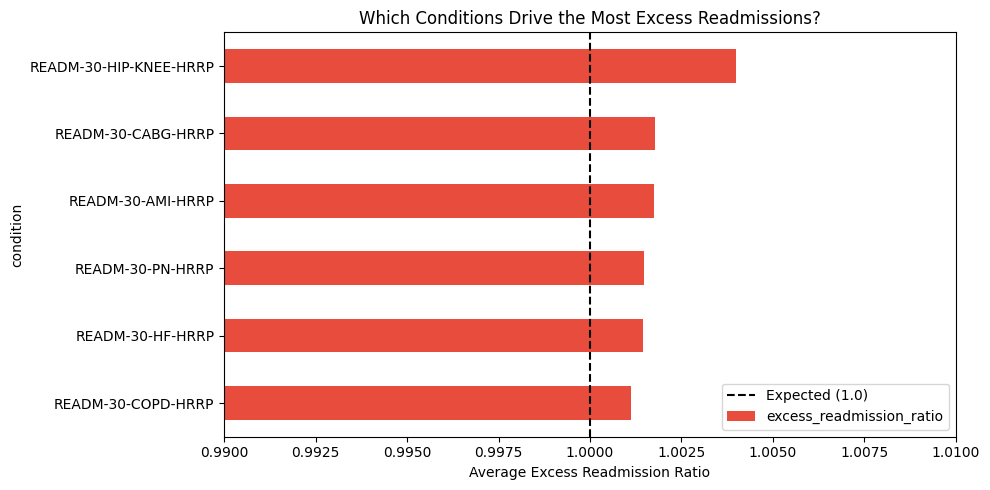

In [39]:
# chart 1: avg ERR by condition
condition_stats = master[master['excess_readmission_ratio'].notna()].groupby('condition')['excess_readmission_ratio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 1.0 else '#3498db' for x in condition_stats.values]
condition_stats.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlim(0.99, 1.01)  # zoom in so you can see the differences
ax.set_xlabel('Average Excess Readmission Ratio')
ax.set_title('Which Conditions Drive the Most Excess Readmissions?')
ax.legend()
plt.tight_layout()
plt.savefig('charts/01_conditions_err.png', dpi=150)
plt.show()

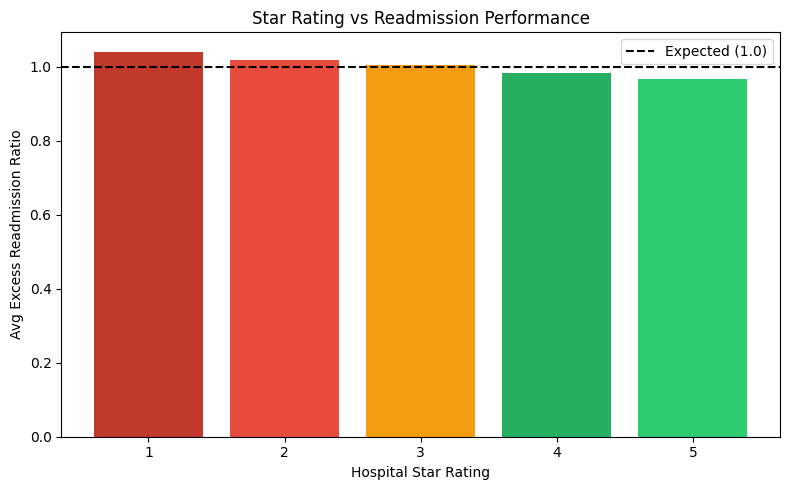

In [40]:
# chart 2: star rating vs avg ERR
star_data = master[master['overall_rating'].notna() & master['excess_readmission_ratio'].notna()]
star_stats = star_data.groupby('overall_rating')['excess_readmission_ratio'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(star_stats.index, star_stats.values, 
       color=['#c0392b', '#e74c3c', '#f39c12', '#27ae60', '#2ecc71'])
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Hospital Star Rating')
ax.set_ylabel('Avg Excess Readmission Ratio')
ax.set_title('Star Rating vs Readmission Performance')
ax.legend()
plt.tight_layout()
plt.savefig('charts/02_star_vs_err.png', dpi=150)
plt.show()


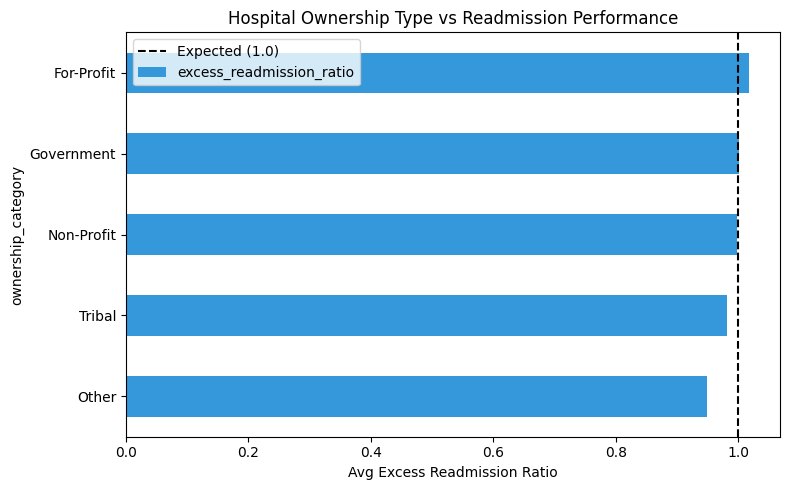

In [41]:
# chart 3: ownership comparison
own_stats = master[master['excess_readmission_ratio'].notna()].groupby('ownership_category')['excess_readmission_ratio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
own_stats.plot(kind='barh', ax=ax, color='#3498db')
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Avg Excess Readmission Ratio')
ax.set_title('Hospital Ownership Type vs Readmission Performance')
ax.legend()
plt.tight_layout()
plt.savefig('charts/03_ownership_err.png', dpi=150)
plt.show()


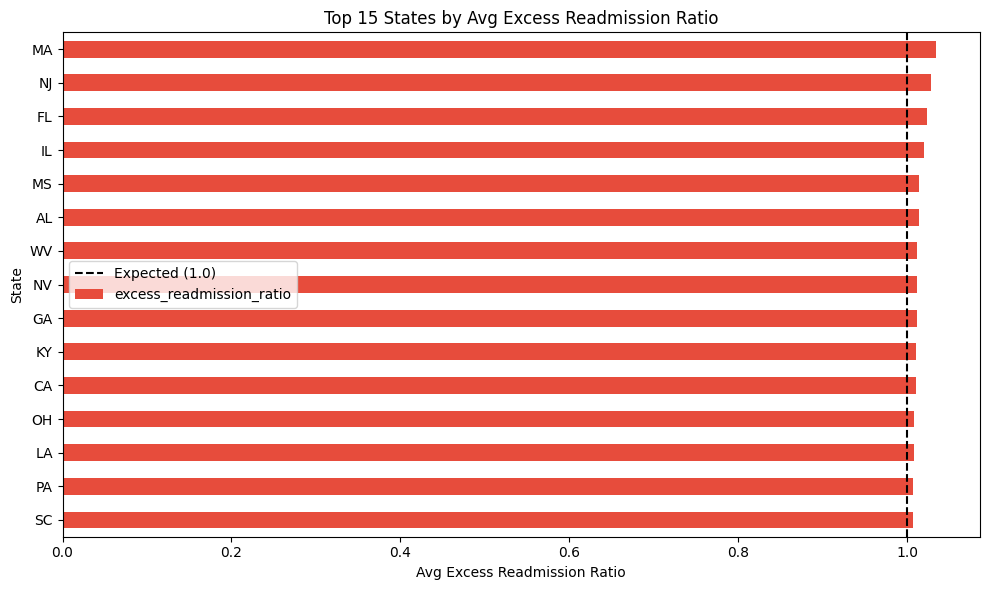

In [42]:
# chart 4: top 15 states by avg excess readmission ratio
state_stats = master[master['excess_readmission_ratio'].notna()].groupby('State')['excess_readmission_ratio'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
state_stats.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#e74c3c')
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Avg Excess Readmission Ratio')
ax.set_title('Top 15 States by Avg Excess Readmission Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_top_states.png', dpi=150)
plt.show()

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_14221/2454879050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y='excess_readmission_ratio', palette='Set2', ax=ax)


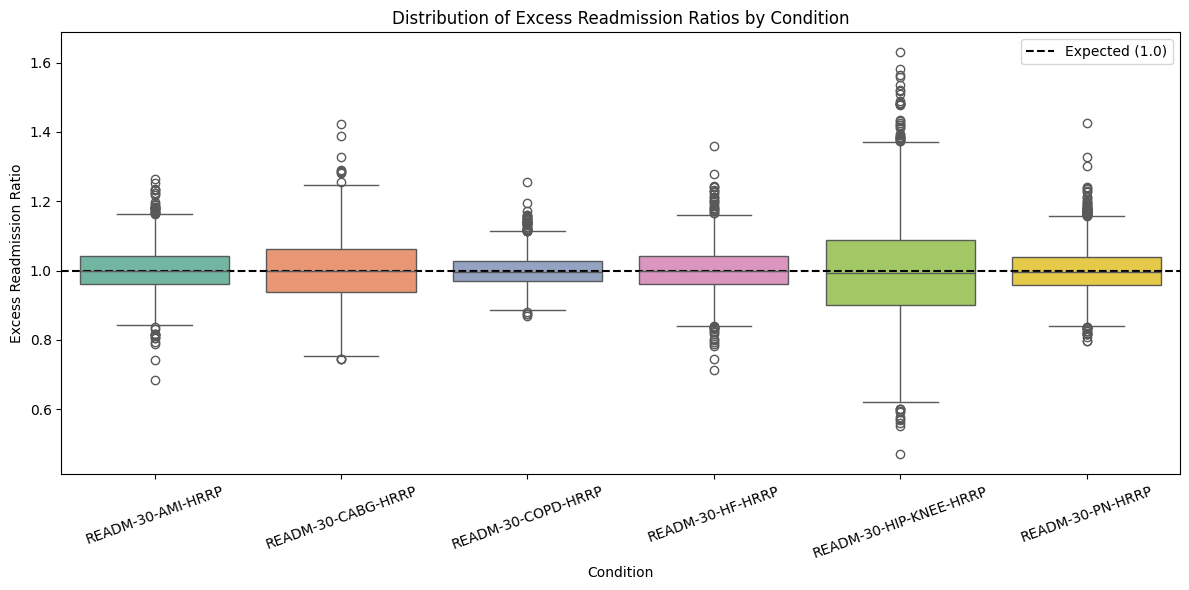

In [43]:
# chart 5: boxplot of ERR by condition - shows the spread, not just the average
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = master[master['excess_readmission_ratio'].notna()]
sns.boxplot(data=plot_data, x='condition', y='excess_readmission_ratio', palette='Set2', ax=ax)
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Condition')
ax.set_ylabel('Excess Readmission Ratio')
ax.set_title('Distribution of Excess Readmission Ratios by Condition')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('charts/05_err_boxplot.png', dpi=150)
plt.show()

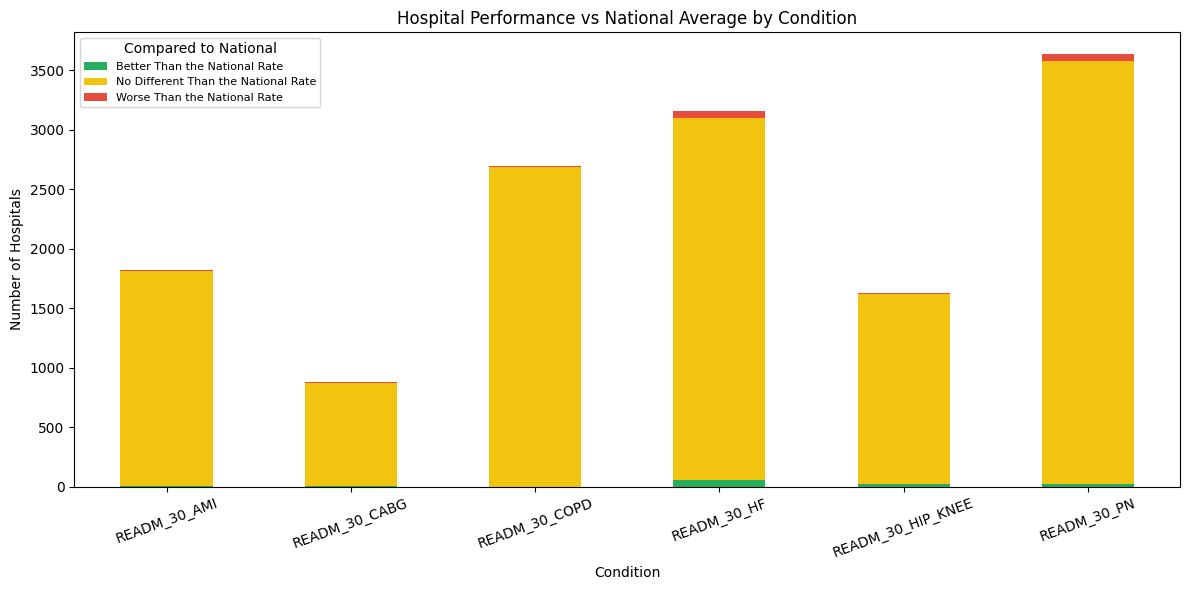

In [44]:
# chart 6: compared to national from the unplanned visits data
readmissions = pd.read_sql("""
    SELECT [Measure ID], [Compared to National], COUNT(*) as cnt
    FROM clean_readmissions
    WHERE readmission_rate IS NOT NULL
    GROUP BY [Measure ID], [Compared to National]
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = readmissions.pivot(index='Measure ID', columns='Compared to National', values='cnt').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#27ae60', '#f1c40f', '#e74c3c'])
ax.set_xlabel('Condition')
ax.set_ylabel('Number of Hospitals')
ax.set_title('Hospital Performance vs National Average by Condition')
ax.legend(title='Compared to National', fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('charts/06_vs_national.png', dpi=150)
plt.show()

In [45]:
# save exploration queries
with open('sql/01_exploration.sql', 'w') as f:
    f.write("""-- data exploration queries
-- checking whats in each table and finding messy values

-- what measure types are in unplanned visits?
SELECT [Measure ID], COUNT(*) as cnt 
FROM raw_unplanned_visits 
GROUP BY [Measure ID];

-- checking for nulls in HRRP
SELECT [Excess Readmission Ratio], COUNT(*) as cnt
FROM raw_hrrp
WHERE [Excess Readmission Ratio] IS NULL 
GROUP BY [Excess Readmission Ratio];

-- messy scores in unplanned visits
SELECT Score, COUNT(*) as cnt
FROM raw_unplanned_visits
WHERE Score = 'Not Available' 
   OR Score IS NULL
GROUP BY Score;

-- how many hospitals in each table?
SELECT 'hospital_info' as tbl, COUNT(DISTINCT [Facility ID]) as cnt FROM raw_hospital_info
UNION ALL
SELECT 'hrrp', COUNT(DISTINCT [Facility ID]) FROM raw_hrrp
UNION ALL
SELECT 'unplanned_visits', COUNT(DISTINCT [Facility ID]) FROM raw_unplanned_visits;

-- usable data per readmission measure
SELECT [Measure ID],
       COUNT(*) as total,
       SUM(CASE WHEN Score != 'Not Available' AND Score IS NOT NULL THEN 1 ELSE 0 END) as has_data,
       SUM(CASE WHEN Score = 'Not Available' OR Score IS NULL THEN 1 ELSE 0 END) as missing
FROM raw_unplanned_visits
WHERE [Measure ID] LIKE 'READM_30%'
GROUP BY [Measure ID];
""")

In [46]:
# save join + analysis queries
with open('sql/03_join_and_analysis.sql', 'w') as f:
    f.write("""-- joining all 3 tables and running analysis

-- master table: hospital info + HRRP penalty data
DROP TABLE IF EXISTS master_hospital;
CREATE TABLE master_hospital AS
SELECT 
    h.[Facility ID],
    h.[Facility Name],
    h.city,
    h.State,
    h.county,
    h.[Hospital Type],
    h.[Hospital Ownership],
    h.ownership_category,
    h.overall_rating,
    h.[Emergency Services],
    p.[Measure Name] as condition,
    p.excess_readmission_ratio,
    p.num_discharges,
    p.num_readmissions
FROM clean_hospital_info h
INNER JOIN clean_hrrp p ON h.[Facility ID] = p.[Facility ID];

-- which conditions have the highest excess readmissions?
SELECT condition,
       COUNT(*) as hospitals_with_data,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_above_expected,
       ROUND(100.0 * SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_above
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY condition
ORDER BY avg_err DESC;

-- for-profit vs non-profit vs government
SELECT ownership_category,
       COUNT(DISTINCT [Facility ID]) as num_hospitals,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY ownership_category
ORDER BY avg_err DESC;

-- star rating vs readmission performance
SELECT overall_rating,
       COUNT(DISTINCT [Facility ID]) as num_hospitals,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
FROM master_hospital
WHERE overall_rating IS NOT NULL
  AND excess_readmission_ratio IS NOT NULL
GROUP BY overall_rating
ORDER BY overall_rating;

-- worst offenders: hospitals failing on 4+ conditions
SELECT [Facility ID], 
       [Facility Name], 
       State, 
       ownership_category,
       overall_rating,
       COUNT(*) as conditions_measured,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as conditions_above_expected,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY [Facility ID], [Facility Name], State, ownership_category, overall_rating
HAVING conditions_above_expected >= 4
ORDER BY conditions_above_expected DESC, avg_err DESC;
""")